In [112]:
import jax
import jax.numpy as jnp
import jax.scipy.ndimage as jndi
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.animation import FuncAnimation

# Force 64-bit precision for physical accuracy
jax.config.update("jax_enable_x64", True)

In [2]:
plt.rcParams['xtick.labelsize'] = 18
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['legend.fontsize'] = 18
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['axes.titlesize'] = 22
plt.rcParams['figure.titlesize'] = 24

In [3]:
class AxisymmetricSwimmers2D:
    def __init__(self, positions, angles, dipole_strengths):
        """
        Initialise N axisymmetric dipole microswimmers in a 2D plane.
    
        Parameters
        -----------
        positions : Array, shape (N, 2)
            (x, y) coordinates of each swimmer
        angles : Array, shape (N, )
            Orientation angle (theta) of each swimmer, measured from the x-axis
        dipole_strengths : Array, shape (N, )
            Scalar dipole strength of each swimmer. 
            Positive for pusher, negative for puller.
        """
        self.positions = jnp.asarray(positions, dtype=jnp.float64)
        self.angles = jnp.asarray(angles, dtype=jnp.float64)
        self.dipole_strengths = jnp.asarray(dipole_strengths, dtype=jnp.float64)

    # For dynamic number of swimmers, just in case I would like to have cell death/birth in the future
    @property
    def count(self):
        """Returns the number of swimmers in the system"""
        return self.positions.shape[0]

    def update_states(self, new_positions, new_angles):
        """Updates kinematic states. Dipole strengths are assumed constant."""
        self.positions = new_positions
        self.angles = new_angles

In [4]:
def build_quasi2d_stokes_solver(Lx, Ly, Lz, Nx, Ny, Nz, mu=1.0, eps=0.1):
    """
    Precomputes the static fluid grids and returns a highly optimised, 
    JIT-compiled pure function to solve the flow field.

    Parameters
    -----------
    Lx, Ly, Lz : Floats
        Dimension of the simulation domain
    Nx, Ny, Nz : Integers
        Number of grid points in each dimension. 
        Should be powers of two for optimal FFT efficiency.
    mu : Float
        Dynamic viscosity
    eps : Float
        Size of Gaussian blob

    Returns
    --------
    solve_flow : JIT-compiled function
        A function to calculate the velocity field of the fluid
    """
    dx, dy, dz = Lx / Nx, Ly / Ny, Lz / Nz
    z_mid = Lz / 2.0
    
    # Precompute all spatial and Fourier grids once
    x = jnp.linspace(0, Lx, Nx, endpoint=False)
    y = jnp.linspace(0, Ly, Ny, endpoint=False)
    z = jnp.linspace(0, Lz, Nz, endpoint=False)
    X, Y, Z = jnp.meshgrid(x, y, z, indexing='ij')
    
    kx = 2 * jnp.pi * jnp.fft.fftfreq(Nx, d=dx)
    ky = 2 * jnp.pi * jnp.fft.fftfreq(Ny, d=dy)
    kz = 2 * jnp.pi * jnp.fft.fftfreq(Nz, d=dz)
    KX, KY, KZ = jnp.meshgrid(kx, ky, kz, indexing='ij')
    
    K2 = KX**2 + KY**2 + KZ**2
    K2_safe = jnp.where(K2 == 0.0, 1.0, K2)

    def _single_swimmer_force(pos_2d, theta, sigma):
        """
        Compute the force density exerted by each swimmer.
    
        Parameters
        -----------
        pos_2d : Array, shape (2, )
            (x, y) coordinates of the swimmer
        theta : Float
            Orientation of the swimmer with respect to the x-axis
        sigma : Float
            Dipole strength, positive for pusher, negative for puller.
    
        Returns
        --------
        force_density : Array, shape (3, Nx, Ny, Nz)
            Force density field due to the swimmer
        """
        px, py = jnp.cos(theta), jnp.sin(theta)
        M_xx, M_xy, M_yy = sigma * px * px, sigma * px * py, sigma * py * py
        
        rx = X - pos_2d[0]
        ry = Y - pos_2d[1]
        rz = Z - z_mid

        # Minimum image convention
        rx -= Lx * jnp.round(rx / Lx)
        ry -= Ly * jnp.round(ry / Ly)
        rz -= Lz * jnp.round(rz / Lz)
        
        r2 = rx**2 + ry**2 + rz**2
        
        prefactor = 1.0 / ((2.0 * jnp.pi)**1.5 * eps**3)
        phi_g = prefactor * jnp.exp(-r2 / (2.0 * eps**2))
        
        f_x = (M_xx * rx + M_xy * ry) * phi_g / (eps**2)
        f_y = (M_xy * rx + M_yy * ry) * phi_g / (eps**2)
        f_z = jnp.zeros_like(f_x)

        force_density = jnp.stack([f_x, f_y, f_z], axis=0)
        
        return force_density
        
    vectorized_spreading = jax.vmap(_single_swimmer_force, in_axes=(0, 0, 0))

    # Compile and return the pure solver function
    @jax.jit
    def solve_flow(positions, angles, sigmas):
        """
        Compute the velocity field due to N microswimmers.
    
        Parameters
        -----------
        positions : Array, shape (N, 2)
            (x, y) coordinates of all swimmers
        angles : Array, shape (N, )
            Orientations of all swimmers with respect to the x-axis
        sigmas : Array, shape (N, )
            Dipole strength of all swimmers, positive for pusher, negative for puller.
    
        Returns
        --------
        u_quasi_2d : Array, shape (2, Nx, Ny)
            Velocity field due to the swimmers in the xy-plane with z at the midpoint.
        """
        all_forces = vectorized_spreading(positions, angles, sigmas)
        total_force = jnp.sum(all_forces, axis=0)
        
        F_hat_x = jnp.fft.fftn(total_force[0])
        F_hat_y = jnp.fft.fftn(total_force[1])
        F_hat_z = jnp.fft.fftn(total_force[2])
        
        k_dot_F_hat = KX * F_hat_x + KY * F_hat_y + KZ * F_hat_z
        
        U_hat_x = (F_hat_x - KX * k_dot_F_hat / K2_safe) / (mu * K2_safe)
        U_hat_y = (F_hat_y - KY * k_dot_F_hat / K2_safe) / (mu * K2_safe)
        
        U_hat_x = U_hat_x.at[0, 0, 0].set(0.0)
        U_hat_y = U_hat_y.at[0, 0, 0].set(0.0)
        
        u_x_3d = jnp.fft.ifftn(U_hat_x).real
        u_y_3d = jnp.fft.ifftn(U_hat_y).real
        
        z_idx = Nz // 2

        u_quasi_2d = jnp.stack([u_x_3d[:, :, z_idx], u_y_3d[:, :, z_idx]], axis=0)
        
        return u_quasi_2d

    # The factory function returns the JIT-compiled function
    return solve_flow

In [5]:
# =============================================================================
# EXECUTION
# =============================================================================
grid_resolution = 256
grid_limit = 0.05*grid_resolution

solver = build_quasi2d_stokes_solver(Lx=grid_limit, Ly=grid_limit, Lz=grid_limit, Nx=grid_resolution, Ny=grid_resolution, Nz=grid_resolution)

# Define 3 swimmers: X, Y positions
positions = [
    [1.0, 2.0],
    [5.0, 9.0],
    [1.2, 7.2]
]

# Orientations: 0 rad (facing right), pi rad (facing left), pi/4 rad (facing up-right)
angles = [0.0, np.pi, np.pi/4.0]

# Dipole strengths: Pusher (>0) and Puller (<0)
sigmas = [-1.0, -1.0, 1.5] 

swimmers = AxisymmetricSwimmers2D(positions, angles, sigmas)

# Solve the flow field
u_quasi_2d = solver(swimmers.positions, swimmers.angles, swimmers.dipole_strengths)

u_x, u_y = u_quasi_2d
u_mag = jnp.sqrt(u_x**2 + u_y**2)

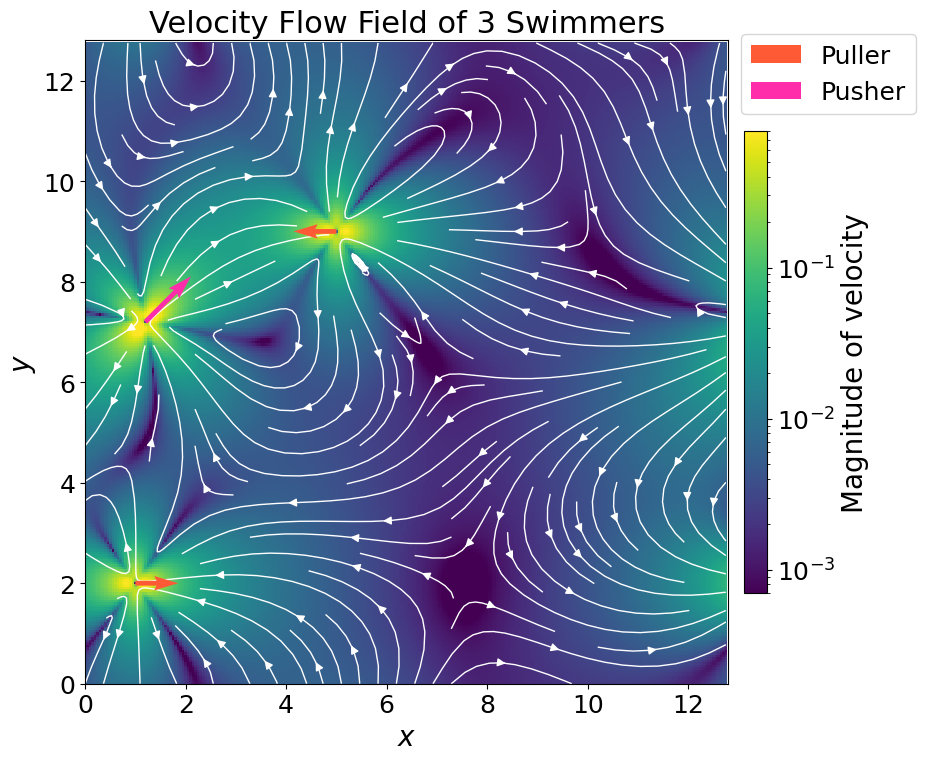

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

x = np.linspace(0, grid_limit, grid_resolution, endpoint=False)
y = np.linspace(0, grid_limit, grid_resolution, endpoint=False)
X, Y = np.meshgrid(x, y)

VMIN = 7e-4
VMAX = 0.8
norm = mcolors.LogNorm(vmin=VMIN, vmax=VMAX)
sm = cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, pad=0.02, shrink=0.6, label="Magnitude of velocity")

ax.set_xlim(0, grid_limit)
ax.set_ylim(0, grid_limit)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')

ax.set_aspect('equal')

# Dictionary to prevent duplicate legend entries
legend_tracker = {"Pusher": False, "Puller": False}

# Plot the positions and orientations of the swimmers as vectors
for i in range(swimmers.count):
    sigma = swimmers.dipole_strengths[i]
    
    # Scale arrow vector components by the absolute dipole strength
    px = np.cos(swimmers.angles[i]) * np.abs(sigma)
    py = np.sin(swimmers.angles[i]) * np.abs(sigma)
    
    # Determine type, color, and assign label
    if sigma > 0:
        color = '#FF2DAA'  # Magenta-ish
        swimmer_type = "Pusher"
    else:
        color = '#FF5A36'  # Orange-ish
        swimmer_type = "Puller"

    # Label the first instance of each type; leave others blank
    if not legend_tracker[swimmer_type]:
        quiver_label = swimmer_type
        legend_tracker[swimmer_type] = True
    else:
        quiver_label = "_"  # Matplotlib ignores labels starting with an underscore
    
    ax.quiver(
        swimmers.positions[i, 0], swimmers.positions[i, 1], 
        px, py, 
        color=color, 
        scale=15,
        scale_units='width',
        zorder=5,
        label=quiver_label
    )

# Add the legend to the axis
ax.legend(loc="upper left", bbox_to_anchor=(1, 1.03))

# Apply the locked 'norm' to the pcolormesh
im = ax.pcolormesh(X, Y, u_mag.T, cmap='viridis', norm=norm, shading='auto', zorder=0)

# Plot Streamlines
ax.streamplot(X, Y, u_x.T, u_y.T, color='white', density=1.2, linewidth=1.0, arrowsize=1.2, zorder=1)

# Formatting
ax.set_title(f"Velocity Flow Field of {swimmers.count:d} Swimmers")

plt.savefig(f"velocity_field_3_swimmers.png", dpi=300, bbox_inches="tight")
plt.show()

#### Incompressibility Check

In [23]:
# =============================================================================
# EXECUTION
# =============================================================================
grid_resolution = 256
grid_limit = 0.05*grid_resolution

# Define 3 swimmers: X, Y positions
positions = [
    [1.0, 2.0],
    [5.0, 9.0],
    [1.2, 7.2]
]

# Orientations: 0 rad (facing right), pi rad (facing left), pi/4 rad (facing up-right)
angles = [0.0, np.pi, np.pi/4.0]

# Dipole strengths: Pusher (>0) and Puller (<0)
sigmas = [-1.0, -1.0, 1.5] 

swimmers = AxisymmetricSwimmers2D(positions, angles, sigmas)

Lx = Ly = Lz = grid_limit
Nx = Ny = Nz = grid_resolution
mu = 1
eps = 0.1

dx, dy, dz = Lx / Nx, Ly / Ny, Lz / Nz
z_mid = Lz / 2.0

# Precompute all spatial and Fourier grids once
x = jnp.linspace(0, Lx, Nx, endpoint=False)
y = jnp.linspace(0, Ly, Ny, endpoint=False)
z = jnp.linspace(0, Lz, Nz, endpoint=False)
X, Y, Z = jnp.meshgrid(x, y, z, indexing='ij')

kx = 2 * jnp.pi * jnp.fft.fftfreq(Nx, d=dx)
ky = 2 * jnp.pi * jnp.fft.fftfreq(Ny, d=dy)
kz = 2 * jnp.pi * jnp.fft.fftfreq(Nz, d=dz)
KX, KY, KZ = jnp.meshgrid(kx, ky, kz, indexing='ij')

K2 = KX**2 + KY**2 + KZ**2
K2_safe = jnp.where(K2 == 0.0, 1.0, K2)

def _single_swimmer_force(pos_2d, theta, sigma):
    """
    Compute the force density exerted by each swimmer.

    Parameters
    -----------
    pos_2d : Array, shape (2, )
        (x, y) coordinates of the swimmer
    theta : Float
        Orientation of the swimmer with respect to the x-axis
    sigma : Float
        Dipole strength, positive for pusher, negative for puller.

    Returns
    --------
    force_density : Array, shape (3, Nx, Ny, Nz)
        Force density field due to the swimmer
    """
    px, py = jnp.cos(theta), jnp.sin(theta)
    M_xx, M_xy, M_yy = sigma * px * px, sigma * px * py, sigma * py * py
    
    rx = X - pos_2d[0]
    ry = Y - pos_2d[1]
    rz = Z - z_mid

    # Minimum image convention
    rx -= Lx * jnp.round(rx / Lx)
    ry -= Ly * jnp.round(ry / Ly)
    rz -= Lz * jnp.round(rz / Lz)
    
    r2 = rx**2 + ry**2 + rz**2
    
    prefactor = 1.0 / ((2.0 * jnp.pi)**1.5 * eps**3)
    phi_g = prefactor * jnp.exp(-r2 / (2.0 * eps**2))
    
    f_x = (M_xx * rx + M_xy * ry) * phi_g / (eps**2)
    f_y = (M_xy * rx + M_yy * ry) * phi_g / (eps**2)
    f_z = jnp.zeros_like(f_x)

    force_density = jnp.stack([f_x, f_y, f_z], axis=0)
    
    return force_density
    
vectorized_spreading = jax.vmap(_single_swimmer_force, in_axes=(0, 0, 0))

# Compile and return the pure solver function
@jax.jit
def solve_flow(positions, angles, sigmas):
    """
    Compute the velocity field due to N microswimmers.

    Parameters
    -----------
    positions : Array, shape (N, 2)
        (x, y) coordinates of all swimmers
    angles : Array, shape (N, )
        Orientations of all swimmers with respect to the x-axis
    sigmas : Array, shape (N, )
        Dipole strength of all swimmers, positive for pusher, negative for puller.

    Returns
    --------
    u_quasi_2d : Array, shape (2, Nx, Ny)
        Velocity field due to the swimmers in the xy-plane with z at the midpoint.
    """
    all_forces = vectorized_spreading(positions, angles, sigmas)
    total_force = jnp.sum(all_forces, axis=0)
    
    F_hat_x = jnp.fft.fftn(total_force[0])
    F_hat_y = jnp.fft.fftn(total_force[1])
    F_hat_z = jnp.fft.fftn(total_force[2])
    
    k_dot_F_hat = KX * F_hat_x + KY * F_hat_y + KZ * F_hat_z
    
    U_hat_x = (F_hat_x - KX * k_dot_F_hat / K2_safe) / (mu * K2_safe)
    U_hat_y = (F_hat_y - KY * k_dot_F_hat / K2_safe) / (mu * K2_safe)
    U_hat_z = (F_hat_z - KZ * k_dot_F_hat / K2_safe) / (mu * K2_safe)
    
    U_hat_x = U_hat_x.at[0, 0, 0].set(0.0)
    U_hat_y = U_hat_y.at[0, 0, 0].set(0.0)
    U_hat_z = U_hat_z.at[0, 0, 0].set(0.0)
    
    return U_hat_x, U_hat_y, U_hat_z

U_hat_x, U_hat_y, U_hat_z = solve_flow(
    swimmers.positions, swimmers.angles, swimmers.dipole_strengths
)

div_U = np.asarray(KX * U_hat_x + KY * U_hat_y + KZ * U_hat_z)

print(f"Max divergence is {np.max(np.abs(div_U)):.2e}")
print(f"90th-percentile divergence is {np.percentile(np.abs(div_U), 90):.2e}")
print(f"80th-percentile divergence is {np.percentile(np.abs(div_U), 80):.2e}")

Max divergence is 5.69e-12
90th-percentile divergence is 4.58e-16
80th-percentile divergence is 9.01e-18


#### Single Swimmer Far-field Decay Check

In [27]:
# =============================================================================
# 1. SETUP SINGLE SWIMMER AT THE CENTER
# =============================================================================
# Place one pusher perfectly in the middle of the box, facing right
grid_resolution = 256
grid_limit = 0.05*grid_resolution

Lx = Ly = Lz = grid_limit
Nx = Ny = Nz = grid_resolution

dx, dy, dz = Lx / Nx, Ly / Ny, Lz / Nz
center_pos = jnp.array([[Lx / 2.0, Ly / 2.0]])
angle = jnp.array([0.0])
sigma = jnp.array([1.0])

grid_resolution = 256
grid_limit = 0.05*grid_resolution

swimmer = AxisymmetricSwimmers2D(center_pos, angle, sigma)

solver = build_quasi2d_stokes_solver(Lx=grid_limit, Ly=grid_limit, Lz=grid_limit, Nx=grid_resolution, Ny=grid_resolution, Nz=grid_resolution)

# Run the solver
u_quasi_2d = solver(swimmer.positions, swimmer.angles, swimmer.dipole_strengths)

u_x, u_y = u_quasi_2d

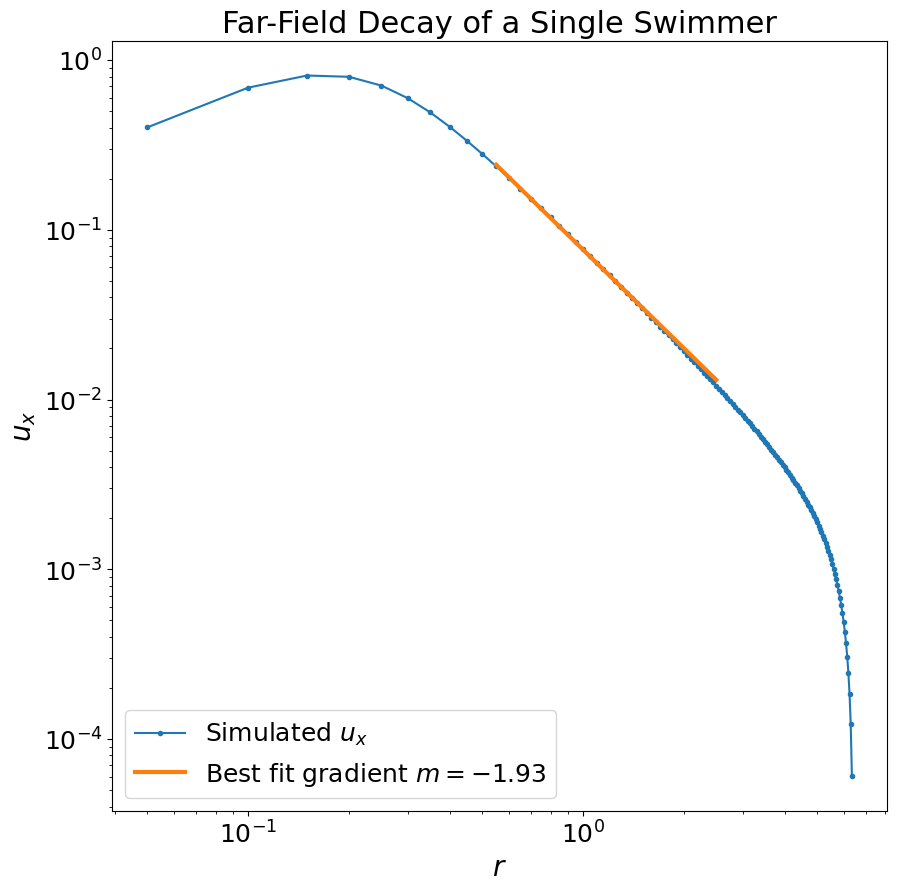

In [79]:
# =============================================================================
# 2. EXTRACT THE 1D SLICE
# =============================================================================
# Find the integer indices for the center of the grid
mid_idx_x = Nx // 2
mid_idx_y = Ny // 2
mid_idx_z = Nz // 2

# We only want to look at points *in front* of the swimmer to avoid log(0) at r=0.
# Slice from the center + 1 grid point, up to the edge of the box
u_x_slice = u_x[mid_idx_x + 1 :, mid_idx_y]

# Calculate the distance 'r' from the swimmer for these points
r_slice = np.arange(1, len(u_x_slice) + 1) * dx

# =============================================================================
# 3. CALCULATE BEST FIT FOR THE MIDDLE 20 POINTS
# =============================================================================
fit_window = 20
fit_start = 10

# Extract the middle 20 points
r_fit = r_slice[fit_start:fit_start+fit_window]
u_fit = u_x_slice[fit_start:fit_start+fit_window]

# Take the log base 10 of both axes
log_r_fit = np.log10(r_fit)
log_u_fit = np.log10(u_fit)

# Perform linear regression (Degree 1 polynomial)
# m is the gradient (power law exponent), c is the y-intercept
m, c = np.polyfit(log_r_fit, log_u_fit, 1)

# =============================================================================
# 4. PLOT THE RESULTS
# =============================================================================
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Plot the full extracted slice
ax.loglog(r_slice, u_x_slice, marker='.', 
          label='Simulated $u_x$', zorder=0)

# Generate the y-values for the line of best fit (reversing the log)
fit_line_y = (10**c) * (r_slice[fit_start:fit_start+2*fit_window]**m)

# Plot the line of best fit over the last 20 points
ax.loglog(r_slice[fit_start:fit_start+2*fit_window], fit_line_y, zorder=2,
          lw=3, label=f'Best fit gradient $m = {m:.2f}$')

# Formatting
ax.set_xlabel(r'$r$')
ax.set_ylabel(r'$u_x$')
ax.set_title('Far-Field Decay of a Single Swimmer')
ax.legend()

plt.show()

### Swimmers have self-propulsion and rotation due to noise

In [7]:
class AxisymmetricSwimmers2D:
    def __init__(self, positions, angles, dipole_strengths):
        """
        Initialise N axisymmetric dipole microswimmers in a 2D plane.
        
        Parameters
        -----------
        positions : Array, shape (N, 2)
            (x, y) coordinates of each swimmer
        angles : Array, shape (N, )
            Orientation angle (theta) of each swimmer, measured from the x-axis
        dipole_strengths : Array, shape (N, )
            Scalar dipole strength of each swimmer. 
            Positive for pusher, negative for puller.
        """
        self.positions = jnp.asarray(positions, dtype=jnp.float64)
        self.angles = jnp.asarray(angles, dtype=jnp.float64)
        self.dipole_strengths = jnp.asarray(dipole_strengths, dtype=jnp.float64)

    @property
    def count(self):
        """Returns the number of swimmers in the system"""
        return self.positions.shape[0]

    def update_states(self, new_positions, new_angles):
        """Updates kinematic states. Dipole strengths are assumed constant."""
        self.positions = new_positions
        self.angles = new_angles


def build_quasi2d_stokes_solver(Lx, Ly, Lz, Nx, Ny, Nz, mu=1.0, eps=0.1):
    """
    Precomputes grids and returns a JIT-compiled function to solve the flow field.
    
    Parameters
    -----------
    Lx, Ly, Lz : Floats
        Dimension of the simulation domain
    Nx, Ny, Nz : Integers
        Number of grid points in each dimension. 
        Should be powers of two for optimal FFT efficiency.
    mu : Float
        Dynamic viscosity
    eps : Float
        Size of Gaussian blob

    Returns
    --------
    solve_flow : JIT-compiled function
        A function to calculate the velocity field of the fluid
    """
    dx, dy, dz = Lx / Nx, Ly / Ny, Lz / Nz
    z_mid = Lz / 2.0
    
    x = jnp.linspace(0, Lx, Nx, endpoint=False)
    y = jnp.linspace(0, Ly, Ny, endpoint=False)
    z = jnp.linspace(0, Lz, Nz, endpoint=False)
    X, Y, Z = jnp.meshgrid(x, y, z, indexing='ij')
    
    kx = 2 * jnp.pi * jnp.fft.fftfreq(Nx, d=dx)
    ky = 2 * jnp.pi * jnp.fft.fftfreq(Ny, d=dy)
    kz = 2 * jnp.pi * jnp.fft.fftfreq(Nz, d=dz)
    KX, KY, KZ = jnp.meshgrid(kx, ky, kz, indexing='ij')
    
    K2 = KX**2 + KY**2 + KZ**2
    K2_safe = jnp.where(K2 == 0.0, 1.0, K2)

    def _single_swimmer_force(pos_2d, theta, sigma):
        """
        Compute the force density exerted by each swimmer.
    
        Parameters
        -----------
        pos_2d : Array, shape (2, )
            (x, y) coordinates of the swimmer
        theta : Float
            Orientation of the swimmer with respect to the x-axis
        sigma : Float
            Dipole strength, positive for pusher, negative for puller.
    
        Returns
        --------
        force_density : Array, shape (3, Nx, Ny, Nz)
            Force density field due to the swimmer
        """
        px, py = jnp.cos(theta), jnp.sin(theta)
        M_xx, M_xy, M_yy = sigma * px * px, sigma * px * py, sigma * py * py
        
        rx = X - pos_2d[0]
        ry = Y - pos_2d[1]
        rz = Z - z_mid

        rx -= Lx * jnp.round(rx / Lx)
        ry -= Ly * jnp.round(ry / Ly)
        rz -= Lz * jnp.round(rz / Lz)
        
        r2 = rx**2 + ry**2 + rz**2
        
        prefactor = 1.0 / ((2.0 * jnp.pi)**1.5 * eps**3)
        phi_g = prefactor * jnp.exp(-r2 / (2.0 * eps**2))
        
        f_x = (M_xx * rx + M_xy * ry) * phi_g / (eps**2)
        f_y = (M_xy * rx + M_yy * ry) * phi_g / (eps**2)
        f_z = jnp.zeros_like(f_x)

        return jnp.stack([f_x, f_y, f_z], axis=0)
        
    vectorized_spreading = jax.vmap(_single_swimmer_force, in_axes=(0, 0, 0))

    @jax.jit
    def solve_flow(positions, angles, sigmas):
        """
        Compute the velocity field due to N microswimmers.
    
        Parameters
        -----------
        positions : Array, shape (N, 2)
            (x, y) coordinates of all swimmers
        angles : Array, shape (N, )
            Orientations of all swimmers with respect to the x-axis
        sigmas : Array, shape (N, )
            Dipole strength of all swimmers, positive for pusher, negative for puller.
    
        Returns
        --------
        u_quasi_2d : Array, shape (2, Nx, Ny)
            Velocity field due to the swimmers in the xy-plane with z at the midpoint.
        """
        all_forces = vectorized_spreading(positions, angles, sigmas)
        total_force = jnp.sum(all_forces, axis=0)
        
        F_hat_x = jnp.fft.fftn(total_force[0])
        F_hat_y = jnp.fft.fftn(total_force[1])
        F_hat_z = jnp.fft.fftn(total_force[2])
        
        k_dot_F_hat = KX * F_hat_x + KY * F_hat_y + KZ * F_hat_z
        
        U_hat_x = (F_hat_x - KX * k_dot_F_hat / K2_safe) / (mu * K2_safe)
        U_hat_y = (F_hat_y - KY * k_dot_F_hat / K2_safe) / (mu * K2_safe)
        
        U_hat_x = U_hat_x.at[0, 0, 0].set(0.0)
        U_hat_y = U_hat_y.at[0, 0, 0].set(0.0)
        
        u_x_3d = jnp.fft.ifftn(U_hat_x).real
        u_y_3d = jnp.fft.ifftn(U_hat_y).real
        
        z_idx = Nz // 2
        return jnp.stack([u_x_3d[:, :, z_idx], u_y_3d[:, :, z_idx]], axis=0)

    return solve_flow


def build_trajectory_generator(Lx, Ly, dt, v0=0.1, Dr=0.01):
    """
    Returns a JIT-compiled function that simulates swimmer trajectories over time
    using active self-propulsion and rotational diffusion.

    Parameters
    -----------
    Lx, Ly : Floats
        Dimensions of the simulation domain
    dt : Float
        Time-step
    v0 : Float
        Self-propulsion velocity of all swimmers (share the same value)
    Dr : Float
        Rotational diffusivity of all swimmers (share the same value)

    Returns
    --------
    wrapper_simulation : JIT-compiled function
        A function which computes the trajectory (position and angle) of 
        all swimmers over time.
    """
    @jax.jit(static_argnames=['num_steps'])
    def wrapper_simulation(initial_positions, initial_angles, num_steps, prng_key):
        """
        The function which computes the trajectory (positions and orientations) of 
        all swimmers over time.
    
        Parameters
        -----------
        initial_positions : Array, shape (N, 2)
            Initial (x, y) coordinates of all swimmers
        initial_angles : Array, shape (N, )
            Initial orientation, as measured from x-axis, of all swimmers
        num_steps : Integer
            Number of timesteps of the simulation
        prng_key: jax.Array
            Starting pseudo-random number generator key
    
        Returns
        --------
        trajectory : tuple of 2 elements
            1st element is the history of positions, a JAX array of shape 
            (num_steps, N, 2).
            2nd element is the history of orientations, a JAX array of shape 
            (num_steps, N).
        """
        def scan_step(carry, _):
            """
            Helper function to be used as an argument for jax.lax.scan. This function 
            will be iterated to update the positions and angles of the swimmers.
        
            Parameters
            -----------
            carry : tuple
                Current (x, y) positions of all swimmers, current orientation of all 
                swimmers, and current random number generator key.
        
            Returns
            --------
            next_carry : tuple
                The value of carry to be used in the next iteration of scan_step.
            outputs : tuple
                The data from the current timestep to be saved, which is (x, y) 
                positions and orientation of all swimmers.
            """
            pos, current_angles, key = carry
            
            # 1. Update positions via active self-propulsion: dx/dt = v0 * p
            px = jnp.cos(current_angles)
            py = jnp.sin(current_angles)
            p = jnp.stack([px, py], axis=-1)
            
            next_pos = pos + v0 * p * dt
            
            # Handle periodic boundaries using modulo arithmetic
            next_pos = next_pos % jnp.array([Lx, Ly])
            
            # 2. Update angles via rotational diffusion: dtheta = sqrt(2*Dr*dt) * xi
            key, subkey = jax.random.split(key)
            noise = jax.random.normal(subkey, shape=current_angles.shape)
            next_angles = current_angles + jnp.sqrt(2.0 * Dr * dt) * noise
            next_angles = next_angles % (2.0 * jnp.pi)
            
            next_carry = (next_pos, next_angles, key)
            outputs = (pos, current_angles)
            return next_carry, outputs

        init_state = (initial_positions, initial_angles, prng_key)
        
        # Run the entire simulation loop natively on hardware
        _, trajectory = jax.lax.scan(scan_step, init_state, None, length=num_steps)
        
        return trajectory

    return wrapper_simulation

In [8]:
# =============================================================================
# INITIALIZATION & EXECUTION
# =============================================================================
grid_resolution = 256
grid_limit = 12.8
dt = 0.1
total_steps = 100

# Instantiate elements
solver = build_quasi2d_stokes_solver(Lx=grid_limit, Ly=grid_limit, Lz=grid_limit, 
                                    Nx=grid_resolution, Ny=grid_resolution, Nz=grid_resolution)

generate_trajectory = build_trajectory_generator(Lx=grid_limit, Ly=grid_limit, dt=dt)

# Define 3 swimmers: X, Y positions
positions = [
    [1.0, 2.0],
    [5.0, 2.6],
    [1.2, 0.8]
]

# Orientations: 0 rad (facing right), pi rad (facing left), pi/4 rad (facing up-right)
angles = [0.0, np.pi, np.pi/4.0]

sigmas = [-1.0, -1.0, 1.5] 

swimmers = AxisymmetricSwimmers2D(positions, angles, sigmas)

# Initialize JAX random state for the noise
key = jax.random.PRNGKey(42)

# Run the compiled time loop to get historical coordinates
pos_history, angle_history = generate_trajectory(
    swimmers.positions, swimmers.angles, num_steps=total_steps, prng_key=key
)

In [12]:
# 1. Compile the solver for a SINGLE time step. 
# This makes the execution incredibly fast without exploding memory.
jitted_solver = jax.jit(solver)

# 2. Prepare a list to hold the numpy arrays
u_history_list = []

# 3. Loop through time sequentially
for t in range(total_steps):
    # Calculate the flow for just this specific frame
    u_jax_at_t = jitted_solver(pos_history[t], angle_history[t], swimmers.dipole_strengths)
    
    # IMMEDIATELY convert to numpy. 
    # This offloads it to standard RAM and lets JAX garbage-collect the huge 3D FFT arrays.
    u_history_list.append(np.asarray(u_jax_at_t))

# 4. Stack the resulting frames into a single NumPy array
# Shape will be exactly as before: (num_steps, 2, Nx, Ny)
u_history_numpy = np.stack(u_history_list)

# Calculate the magnitude array for the animation
u_history_mag = np.linalg.norm(u_history_numpy, axis=1)

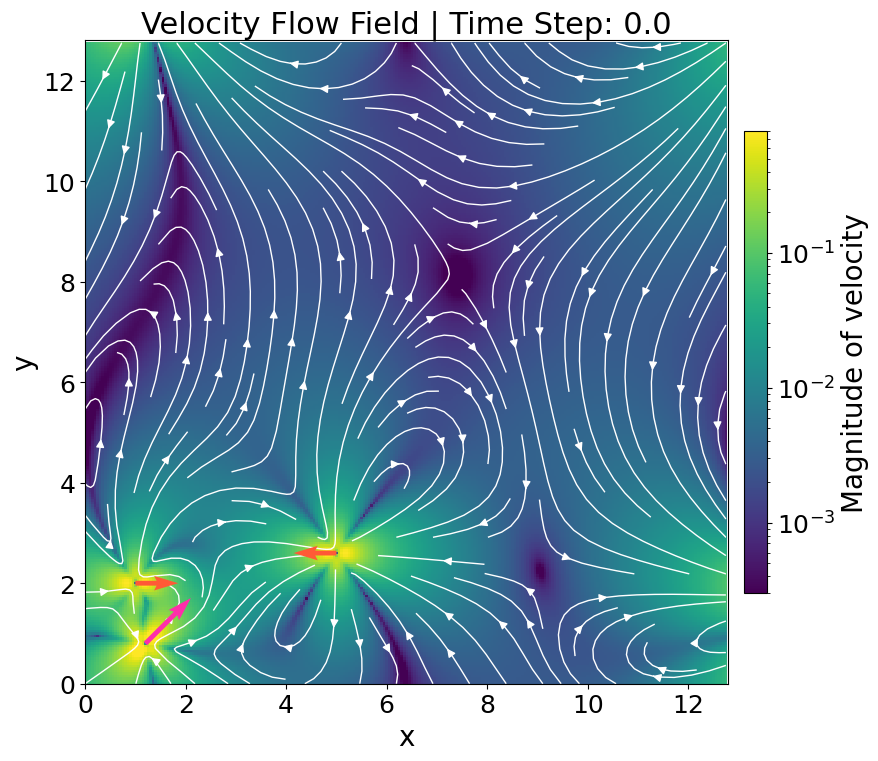

In [17]:
# 1. Convert JAX history arrays to NumPy for Matplotlib compatibility
pos_history_np = np.asarray(pos_history)
angle_history_np = np.asarray(angle_history)

# 2. Setup the static figure and grids
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

x = np.linspace(0, grid_limit, grid_resolution, endpoint=False)
y = np.linspace(0, grid_limit, grid_resolution, endpoint=False)
X, Y = np.meshgrid(x, y)

# 3. Configure the static Colorbar (done outside the animation loop)
VMIN = 3e-4
VMAX = 0.8
norm = mcolors.LogNorm(vmin=VMIN, vmax=VMAX)
sm = cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, pad=0.02, shrink=0.6, label="Magnitude of velocity")

ax.set_xlim(0, grid_limit)
ax.set_ylim(0, grid_limit)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')
ax.set_aspect('equal')

# 4. Define the update function for each frame
def update(frame):
    # Clear the axis to remove old streamplots and quivers
    ax.clear()
    
    # Re-apply static formatting
    ax.set_xlim(0, grid_limit)
    ax.set_ylim(0, grid_limit)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal')
    ax.set_title(f"Velocity Flow Field | Time Step: {dt*frame:.1f}")
    
    # Extract data for the current frame
    u_mag_t = u_history_mag[frame]
    u_x_t = u_history_numpy[frame, 0]
    u_y_t = u_history_numpy[frame, 1]
    
    # Redraw the background velocity magnitude heatmap
    ax.pcolormesh(X, Y, u_mag_t.T, cmap='viridis', norm=norm, shading='auto', zorder=0)
    
    # Redraw the streamlines
    ax.streamplot(X, Y, u_x_t.T, u_y_t.T, color='white', density=1.2, 
                  linewidth=1.0, arrowsize=1.2, zorder=1)
    
    # Dictionary to prevent duplicate legend entries
    legend_tracker = {"Pusher": False, "Puller": False}
    
    # Redraw the swimmers for the current frame
    for i in range(swimmers.count):
        sigma = swimmers.dipole_strengths[i]
        current_angle = angle_history_np[frame, i]
        current_pos_x = pos_history_np[frame, i, 0]
        current_pos_y = pos_history_np[frame, i, 1]
        
        # Scale arrow vector components by the absolute dipole strength
        px = np.cos(current_angle) * np.abs(sigma)
        py = np.sin(current_angle) * np.abs(sigma)
        
        if sigma > 0:
            color = '#FF2DAA'  # Magenta-ish
            swimmer_type = "Pusher"
        else:
            color = '#FF5A36'  # Orange-ish
            swimmer_type = "Puller"

        if not legend_tracker[swimmer_type]:
            quiver_label = swimmer_type
            legend_tracker[swimmer_type] = True
        else:
            quiver_label = "_"
        
        ax.quiver(
            current_pos_x, current_pos_y, 
            px, py, 
            color=color, 
            scale=15,
            scale_units='width',
            zorder=5,
            label=quiver_label
        )
        
    # Re-add the legend

# 6. Create the animation
ani = FuncAnimation(fig, update, frames=total_steps, interval=50, blit=False)

# 7. Save the animation
output_filename = "3_swimmers_flow_field.mp4"
ani.save(output_filename, writer='ffmpeg', fps=10, dpi=300)

#### Mean Squared Displacement Check

In [110]:
Lx = Ly = 12.8
dt = 0.1
v0 = 0.1
Dr = 0.01

@jax.jit(static_argnames=['num_steps'])
def wrapper_simulation(initial_positions, initial_angles, num_steps, prng_key):
    """
    The function which computes the trajectory (positions and orientations) of 
    all swimmers over time.

    Parameters
    -----------
    initial_positions : Array, shape (N, 2)
        Initial (x, y) coordinates of all swimmers
    initial_angles : Array, shape (N, )
        Initial orientation, as measured from x-axis, of all swimmers
    num_steps : Integer
        Number of timesteps of the simulation
    prng_key: jax.Array
        Starting pseudo-random number generator key

    Returns
    --------
    trajectory : tuple of 2 elements
        1st element is the history of positions, a JAX array of shape 
        (num_steps, N, 2).
        2nd element is the history of orientations, a JAX array of shape 
        (num_steps, N).
    """
    def scan_step(carry, _):
        """
        Helper function to be used as an argument for jax.lax.scan. This function 
        will be iterated to update the positions and angles of the swimmers.
    
        Parameters
        -----------
        carry : tuple
            Current (x, y) positions of all swimmers, current orientation of all 
            swimmers, and current random number generator key.
    
        Returns
        --------
        next_carry : tuple
            The value of carry to be used in the next iteration of scan_step.
        outputs : tuple
            The data from the current timestep to be saved, which is (x, y) 
            positions and orientation of all swimmers.
        """
        pos, current_angles, key = carry
        
        # 1. Update positions via active self-propulsion: dx/dt = v0 * p
        px = jnp.cos(current_angles)
        py = jnp.sin(current_angles)
        p = jnp.stack([px, py], axis=-1)
        
        next_pos = pos + v0 * p * dt
        
        # 2. Update angles via rotational diffusion: dtheta = sqrt(2*Dr*dt) * xi
        key, subkey = jax.random.split(key)
        noise = jax.random.normal(subkey, shape=current_angles.shape)
        next_angles = current_angles + jnp.sqrt(2.0 * Dr * dt) * noise
        next_angles = next_angles % (2.0 * jnp.pi)
        
        next_carry = (next_pos, next_angles, key)
        outputs = (pos, current_angles)
        return next_carry, outputs

    init_state = (initial_positions, initial_angles, prng_key)
    
    # Run the entire simulation loop natively on hardware
    _, trajectory = jax.lax.scan(scan_step, init_state, None, length=num_steps)
    
    return trajectory

num_swimmers = 100
total_time = int(2e4)
time_array = np.arange(0, total_time, dt)
num_steps = int(total_time / dt)

key = jax.random.PRNGKey(42)
key_1, key_2 = jax.random.split(key)
initial_angles = jax.random.uniform(key_1, shape=(num_swimmers, ), minval=0.0, maxval=2*jnp.pi, )
initial_pos = jnp.zeros((num_swimmers, 2))

trajectory = wrapper_simulation(initial_pos, initial_angles, num_steps, key_2)
pos_history = np.asarray(trajectory[0])
squared_displacements = np.sum(pos_history**2, axis=2)

msd = np.mean(squared_displacements, axis=1)
msd_theoretical = (2 * v0**2 / Dr**2) * (Dr * time_array - 1 + np.exp(-Dr * time_array))

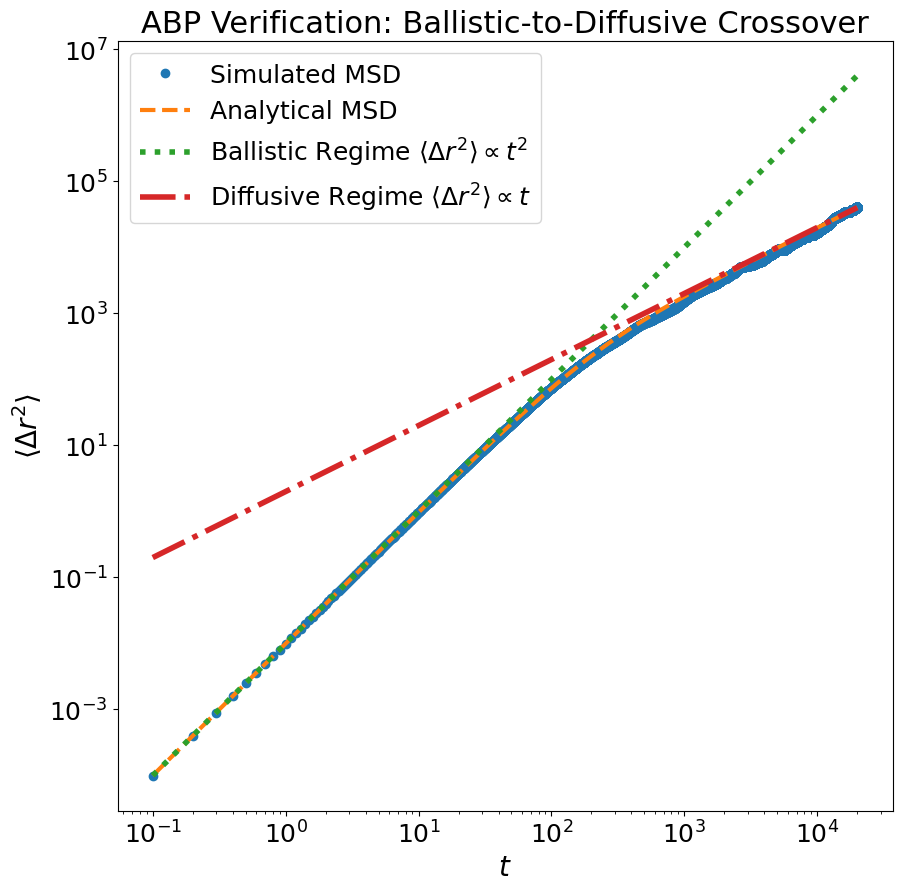

In [111]:
# =============================================================================
# 5. PLOT THE LOG-LOG GRAPH
# =============================================================================
plt.figure(figsize=(10, 10))

# Plot simulated and theoretical MSD
# Skip the first element because log(0) is undefined
plt.loglog(time_array[1:], msd[1:], 'o', label='Simulated MSD')
plt.loglog(time_array[1:], msd_theoretical[1:], '--', linewidth=3, label='Analytical MSD')

# --- Guide Lines for Slopes ---
# Ballistic regime guide line (Slope = 2) at early times
guide_ballistic = (v0**2) * (time_array[1:]**2)
plt.loglog(time_array[1:], guide_ballistic, ':', linewidth=4, 
           label=r'Ballistic Regime $\langle \Delta r^2 \rangle \propto t^2$')

# Diffusive regime guide line (Slope = 1) at late times
guide_diffusive = 2 * v0**2 * time_array[1:] / Dr
plt.loglog(time_array[1:], guide_diffusive, '-.', linewidth=4, 
           label=r'Diffusive Regime $\langle \Delta r^2 \rangle \propto t$')

# Formatting
plt.xlabel(r'$t$')
plt.ylabel(r'$\langle \Delta r^2 \rangle$')
plt.title('ABP Verification: Ballistic-to-Diffusive Crossover')
plt.legend()

plt.show()

### Couple ABP with Stokes Flow

In [113]:
class AxisymmetricSwimmers2D:
    def __init__(self, positions, angles, dipole_strengths):
        """
        Initialise N axisymmetric dipole microswimmers in a 2D plane.
    
        Parameters
        -----------
        positions : Array, shape (N, 2)
            (x, y) coordinates of each swimmer
        angles : Array, shape (N, )
            Orientation angle (theta) of each swimmer, measured from the x-axis
        dipole_strengths : Array, shape (N, )
            Scalar dipole strength of each swimmer. 
            Positive for pusher, negative for puller.
        """
        self.positions = jnp.asarray(positions, dtype=jnp.float64)
        self.angles = jnp.asarray(angles, dtype=jnp.float64)
        self.dipole_strengths = jnp.asarray(dipole_strengths, dtype=jnp.float64)

    # For dynamic number of swimmers, just in case I would like to have cell death/birth in the future
    @property
    def count(self):
        """Returns the number of swimmers in the system"""
        return self.positions.shape[0]

    def update_states(self, new_positions, new_angles):
        """Updates kinematic states. Dipole strengths are assumed constant."""
        self.positions = new_positions
        self.angles = new_angles

In [ ]:
def build_quasi2d_stokes_solver(Lx, Ly, Lz, Nx, Ny, Nz, mu=1.0, eps=0.1):
    """
    Precomputes grids and returns a JIT-compiled function to solve the flow field.
    
    Parameters
    -----------
    Lx, Ly, Lz : Floats
        Dimension of the simulation domain
    Nx, Ny, Nz : Integers
        Number of grid points in each dimension. 
        Should be powers of two for optimal FFT efficiency.
    mu : Float
        Dynamic viscosity
    eps : Float
        Size of Gaussian blob

    Returns
    --------
    solve_flow : JIT-compiled function
        A function to calculate the velocity field of the fluid
    """
    dx, dy, dz = Lx / Nx, Ly / Ny, Lz / Nz
    z_mid = Lz / 2.0
    
    x = jnp.linspace(0, Lx, Nx, endpoint=False)
    y = jnp.linspace(0, Ly, Ny, endpoint=False)
    z = jnp.linspace(0, Lz, Nz, endpoint=False)
    X, Y, Z = jnp.meshgrid(x, y, z, indexing='ij')
    
    kx = 2 * jnp.pi * jnp.fft.fftfreq(Nx, d=dx)
    ky = 2 * jnp.pi * jnp.fft.fftfreq(Ny, d=dy)
    kz = 2 * jnp.pi * jnp.fft.fftfreq(Nz, d=dz)
    KX, KY, KZ = jnp.meshgrid(kx, ky, kz, indexing='ij')
    
    K2 = KX**2 + KY**2 + KZ**2
    K2_safe = jnp.where(K2 == 0.0, 1.0, K2)

    def _single_swimmer_force(pos_2d, theta, sigma):
        px, py = jnp.cos(theta), jnp.sin(theta)
        M_xx, M_xy, M_yy = sigma * px * px, sigma * px * py, sigma * py * py
        
        rx, ry, rz = X - pos_2d[0], Y - pos_2d[1], Z - z_mid

        rx -= Lx * jnp.round(rx / Lx)
        ry -= Ly * jnp.round(ry / Ly)
        rz -= Lz * jnp.round(rz / Lz)
        
        r2 = rx**2 + ry**2 + rz**2
        
        prefactor = 1.0 / ((2.0 * jnp.pi)**1.5 * eps**3)
        phi_g = prefactor * jnp.exp(-r2 / (2.0 * eps**2))
        
        f_x = (M_xx * rx + M_xy * ry) * phi_g / (eps**2)
        f_y = (M_xy * rx + M_yy * ry) * phi_g / (eps**2)
        f_z = jnp.zeros_like(f_x)

        return jnp.stack([f_x, f_y, f_z], axis=0)
        
    vectorized_spreading = jax.vmap(_single_swimmer_force, in_axes=(0, 0, 0))

    @jax.jit
    def solve_flow(positions, angles, sigmas):
        all_forces = vectorized_spreading(positions, angles, sigmas)
        total_force = jnp.sum(all_forces, axis=0)
        
        F_hat_x = jnp.fft.fftn(total_force[0])
        F_hat_y = jnp.fft.fftn(total_force[1])
        F_hat_z = jnp.fft.fftn(total_force[2])
        
        k_dot_F_hat = KX * F_hat_x + KY * F_hat_y + KZ * F_hat_z
        
        U_hat_x = (F_hat_x - KX * k_dot_F_hat / K2_safe) / (mu * K2_safe)
        U_hat_y = (F_hat_y - KY * k_dot_F_hat / K2_safe) / (mu * K2_safe)
        
        U_hat_x = U_hat_x.at[0, 0, 0].set(0.0)
        U_hat_y = U_hat_y.at[0, 0, 0].set(0.0)
        
        # --- NEW: Calculate Vorticity in Fourier Space ---
        # w_z = d(u_y)/dx - d(u_x)/dy  ->  i * kx * U_hat_y - i * ky * U_hat_x
        Vort_hat_z = 1j * KX * U_hat_y - 1j * KY * U_hat_x
        
        u_x_3d = jnp.fft.ifftn(U_hat_x).real
        u_y_3d = jnp.fft.ifftn(U_hat_y).real
        vort_z_3d = jnp.fft.ifftn(Vort_hat_z).real
        
        # Slice at the mid-plane
        z_idx = Nz // 2
        u_x_2d = u_x_3d[:, :, z_idx]
        u_y_2d = u_y_3d[:, :, z_idx]
        vort_z_2d = vort_z_3d[:, :, z_idx]

        # --- NEW: Interpolate grid values to particle positions ---
        # Convert physical coordinates to fractional grid indices
        x_idx = positions[:, 0] / dx
        y_idx = positions[:, 1] / dy
        coords = jnp.stack([x_idx, y_idx], axis=0)
        
        # order=1 ensures bilinear interpolation, mode='wrap' handles PBCs perfectly
        u_fluid_x = jndi.map_coordinates(u_x_2d, coords, order=1, mode='wrap')
        u_fluid_y = jndi.map_coordinates(u_y_2d, coords, order=1, mode='wrap')
        vort_fluid_z = jndi.map_coordinates(vort_z_2d, coords, order=1, mode='wrap')
        
        u_fluid = jnp.stack([u_fluid_x, u_fluid_y], axis=-1)
        
        # Note on physics: By Faxen's Law, the rotation rate of a rigid particle in a flow 
        # is exactly HALF the local vorticity. 
        omega_fluid = 0.5 * vort_fluid_z

        return u_fluid, omega_fluid

    return solve_flow